# Analyse de l'effet des chocs des prix internationaux du pétrole sur l'inflation à Madagascar
## Approche SVAR (2000-2025)

---

**Contexte :** Madagascar est fortement dépendante des importations de produits pétroliers. Les fluctuations des prix internationaux du pétrole influencent les coûts de transport, les coûts de production et, par conséquent, le niveau général des prix.

**Objectif :** Mesurer et analyser l'impact des chocs pétroliers sur l'inflation malgache à l'aide d'un modèle SVAR (Structural Vector Autoregression).

**Période :** Janvier 2000 - Janvier 2025 (données mensuelles)

**Variables :**
- **OIL** : Prix du pétrole Brent (USD/baril) — Banque Mondiale (Pink Sheet)
- **EXR** : Taux de change MGA/USD
- **M2** : Masse monétaire
- **INF** : Indice des Prix à la Consommation (IPC) — INSTAT Madagascar

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import VAR, SVAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.var_model import VARResults
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.vector_ar.var_model import FEVD
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from scipy.stats import chi2, norm, jarque_bera
from statsmodels.tsa.stattools import acf

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 120)

# Parametres
P_LAGS = 8  # Nombre de retards
PERIODES_IRF = 30
VARIABLES = ['OIL', 'EXR', 'M2', 'INF']

print("Bibliotheques chargees.")

Bibliotheques chargees.


---
## 1. Collecte et chargement des données

In [15]:
DATA_DIR = 'data/processed'
# Charger directement les sources pour OIL et INF.
# OIL provient de oil_brent_clean.csv et INF provient de instat_cpi_clean.csv.
oil = pd.read_csv(f'{DATA_DIR}/oil_brent_clean.csv', index_col=0, parse_dates=True)
# Convertir les dates fin de mois en début de mois pour aligner avec data.csv.
oil.index = oil.index.to_period('M').to_timestamp('D', 'start')
oil = oil.rename(columns={'OIL_Brent': 'OIL'})

cpi = pd.read_csv(f'{DATA_DIR}/instat_cpi_clean.csv', index_col=0, parse_dates=True)
cpi = cpi[['IPC_Niveau']].rename(columns={'IPC_Niveau': 'INF'})

# Charger les autres variables et dummies déjà assemblées dans data.csv.
df_orig = pd.read_csv(f'{DATA_DIR}/data.csv', index_col=0, parse_dates=True)
df = df_orig.copy()
df['OIL'] = oil['OIL']
# Utiliser les valeurs INSTAT quand elles sont disponibles, sinon conserver l'ancien INF.
df['INF'] = cpi['INF'].combine_first(df['INF'])

dummy_cols = [c for c in df.columns if c.startswith('D')]
var_cols = [c for c in df.columns if not c.startswith('D')]
df_vars = df[var_cols]
dummies = df[dummy_cols] if dummy_cols else None

print(f"Dimensions : {df_vars.shape}")
print(f"Periode : {df_vars.index[0].date()} a {df_vars.index[-1].date()}")
print(f"Frequence : {pd.infer_freq(df_vars.index)}")
print(f"Variables : {list(var_cols)}")
if dummies is not None:
    print(f"Dummies : {list(dummy_cols)}")
df_vars.head()

Dimensions : (301, 4)
Periode : 2000-01-01 a 2025-01-01
Frequence : MS
Variables : ['OIL', 'EXR', 'M2', 'INF']
Dummies : ['D2008', 'D2020', 'D2022']


,OIL,EXR,M2,INF
Date,,,,
2000-01-01,25.38,1353.5,1.090952e+12,25.81
2000-02-01,27.70,1353.5,1.090952e+12,25.81
2000-03-01,27.47,1353.5,1.090952e+12,25.81
2000-04-01,22.54,1353.5,1.090952e+12,25.81
2000-05-01,27.34,1353.5,1.090952e+12,25.81


---
## 2. Analyse descriptive

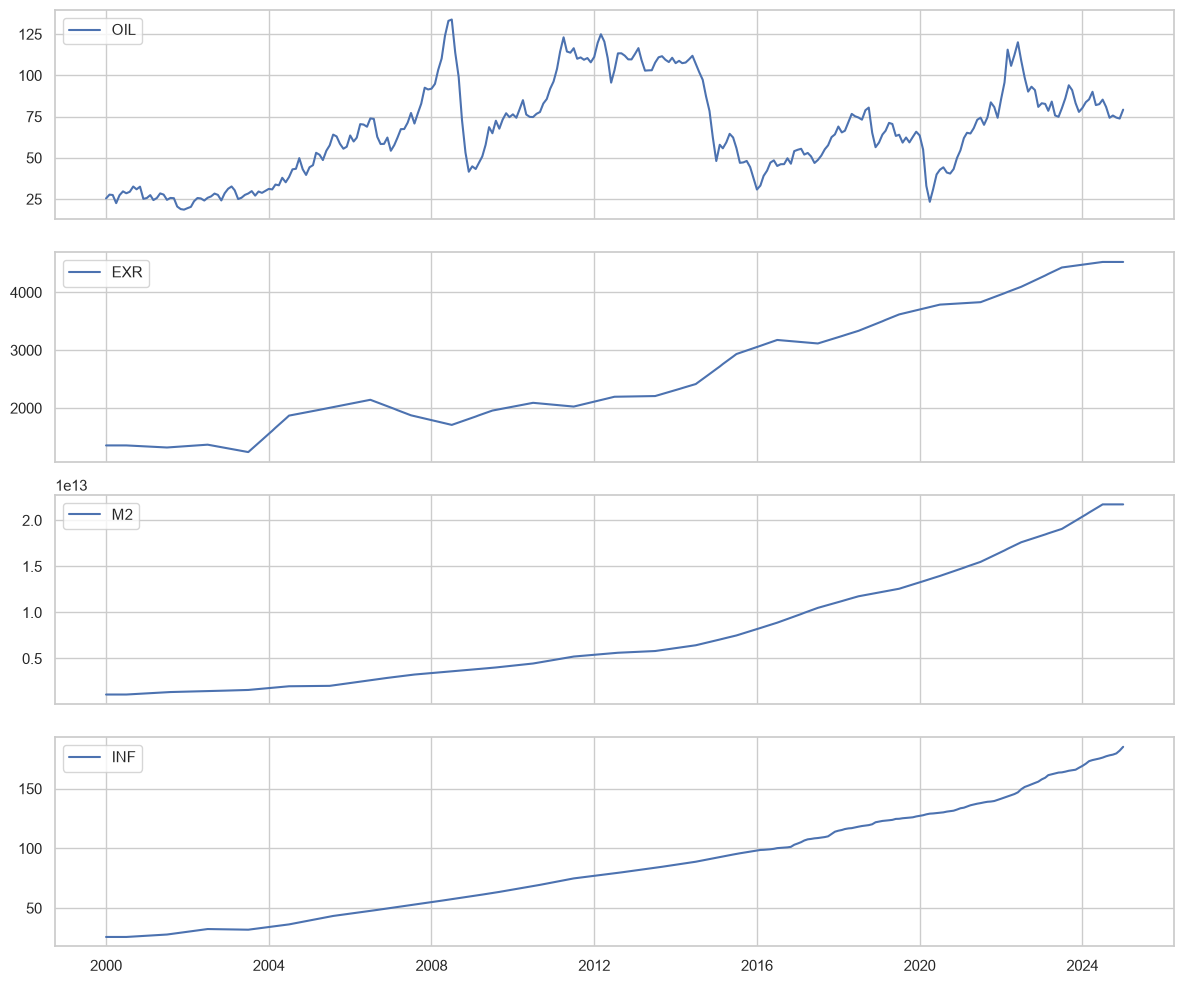


Statistiques descriptives :
          OIL      EXR            M2     INF
count  301.00   301.00  3.010000e+02  301.00
mean    66.80  2585.52  7.595868e+12   84.78
std     28.68   996.83  6.018299e+12   43.94
min     18.60  1238.33  1.090952e+12   25.81
25%     44.28  1873.88  2.502992e+12   46.49
50%     64.91  2194.97  5.606324e+12   79.12
75%     85.30  3405.64  1.195557e+13  119.47
max    133.87  4525.42  2.172348e+13  185.04


In [16]:
fig, axes = plt.subplots(len(var_cols), 1, figsize=(12, 10), sharex=True)
for ax, col in zip(axes, var_cols):
    ax.plot(df_vars.index, df_vars[col], linewidth=1.5, label=col)
    ax.legend(loc='upper left', fontsize=11)
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

print("\nStatistiques descriptives :")
print(df_vars.describe().round(2))

---
## 3. Tests de stationnarité (ADF et Phillips-Perron)

On teste toutes les variables en niveau et en première différence pour vérifier qu'elles sont intégrées d'ordre 1 (I(1)).

In [17]:
def test_adf_pp(series, name):
    y = series.dropna()
    # ADF
    adf = adfuller(y, autolag='AIC')
    # PP (simple)
    vals = y.values
    n_pp = len(vals)
    dy = np.diff(vals)
    y_lag = vals[:-1]
    X_pp = add_constant(np.column_stack([y_lag, np.arange(n_pp - 1)]))
    res_pp = OLS(dy, X_pp).fit()
    rho = res_pp.params[1]
    se = res_pp.bse[1]
    stat_pp = (rho - 1) / se
    pval_pp = 2 * norm.cdf(-abs(stat_pp))
    return adf, (stat_pp, pval_pp)


print("=" * 70)
print("TESTS DE STATIONNARITE (ADF & PP)")
print("=" * 70)

for col in var_cols:
    adf, pp = test_adf_pp(df_vars[col], col)
    adf_stat = f"ADF={adf[0]:.4f}, p={adf[1]:.4f} => {'Stationnaire' if adf[1] <= 0.05 else 'Non-stationnaire'}"
    pp_stat = f"PP={pp[0]:.4f}, p={pp[1]:.4f} => {'Stationnaire' if pp[1] <= 0.05 else 'Non-stationnaire'}"
    print(f"\n{col}:")
    print(f"  {adf_stat}")
    print(f"  {pp_stat}")

# Differentiation
df_d1 = df_vars.diff().dropna()
print("\n" + "=" * 70)
print("SERIES DIFFERENCIEES (I(1))")
print("=" * 70)

for col in df_d1.columns:
    adf, pp = test_adf_pp(df_d1[col], f"{col} (diff)")
    print(f"\n{col} (diff):")
    print(f"  ADF={adf[0]:.4f}, p={adf[1]:.4f} => {'Stationnaire' if adf[1] <= 0.05 else 'Non-stationnaire'}")
    print(f"  PP={pp[0]:.4f}, p={pp[1]:.4f} => {'Stationnaire' if pp[1] <= 0.05 else 'Non-stationnaire'}")

TESTS DE STATIONNARITE (ADF & PP)

OIL:
  ADF=-2.6909, p=0.0756 => Non-stationnaire
  PP=-78.6667, p=0.0000 => Stationnaire

EXR:
  ADF=0.1244, p=0.9677 => Non-stationnaire
  PP=-288.7075, p=0.0000 => Stationnaire

M2:
  ADF=1.0916, p=0.9951 => Non-stationnaire
  PP=-933.7261, p=0.0000 => Stationnaire

INF:
  ADF=3.3344, p=1.0000 => Non-stationnaire
  PP=-360.6552, p=0.0000 => Stationnaire

SERIES DIFFERENCIEES (I(1))

OIL (diff):
  ADF=-12.1517, p=0.0000 => Stationnaire
  PP=-30.3627, p=0.0000 => Stationnaire

EXR (diff):
  ADF=-3.2488, p=0.0173 => Stationnaire
  PP=-46.2496, p=0.0000 => Stationnaire

M2 (diff):
  ADF=-1.2008, p=0.6732 => Non-stationnaire
  PP=-39.6949, p=0.0000 => Stationnaire

INF (diff):
  ADF=-1.0218, p=0.7452 => Non-stationnaire
  PP=-27.2128, p=0.0000 => Stationnaire


---
## 4. Test de cointégration (Johansen)

On vérifie l'existence de relations de long terme entre les variables.

In [18]:
print("Test de cointegration de Johansen :")
print("-" * 50)

# Le test Johansen ne supporte pas les valeurs manquantes : utiliser uniquement les observations complètes.
sub = df_vars.dropna()
if len(sub) == 0:
    raise ValueError("Aucune observation complete disponible pour le test de cointegration.")

johansen = None
for k in [2, 1]:
    try:
        johansen = coint_johansen(sub.values, det_order=0, k_ar_diff=k)
        print(f"Johansen calcule avec k_ar_diff={k}.")
        break
    except np.linalg.LinAlgError as err:
        print(f"LinAlgError avec k_ar_diff={k} : {err}")

if johansen is None:
    print("Echec du test de cointegration de Johansen (SVD n'a pas converge).")
else:
    print(f"Statistiques de la trace : {johansen.lr1.round(3)}")
    print(f"Valeurs critiques (95%) :  {johansen.cvt[:, 1].round(3)}")
    print(f"Statistiques lambda max :  {johansen.lr2.round(3)}")
    print(f"Valeurs critiques (95%) :  {johansen.cvm[:, 1].round(3)}")

    r = sum(johansen.lr1 > johansen.cvt[:, 1])
    print(f"\nNombre de relations de cointegration : {r}")
    if r > 0:
        print("\n[Note] Presence de cointegration -> un VECM serait alternativement approprié.")
        print("        Le SVAR en differences reste valide apres differentiation.")
    else:
        print("\n[Note] Aucune relation de cointegration detectee -> le SVAR en differences reste valide.")

Test de cointegration de Johansen :
--------------------------------------------------
Johansen calcule avec k_ar_diff=2.
Statistiques de la trace : [64.768 30.396 12.9    3.347]
Valeurs critiques (95%) :  [47.854 29.796 15.494  3.842]
Statistiques lambda max :  [34.372 17.496  9.553  3.347]
Valeurs critiques (95%) :  [27.586 21.131 14.264  3.842]

Nombre de relations de cointegration : 2

[Note] Presence de cointegration -> un VECM serait alternativement approprié.
        Le SVAR en differences reste valide apres differentiation.


---
## 5. Sélection du nombre de retards

In [19]:
print("Selection du retard optimal (AIC, BIC, HQIC, FPE) :")
print("=" * 50)

var_select = VAR(df_d1)
selection = var_select.select_order(maxlags=12)
print(selection.summary())

print(f"\nRetard retenu (AIC) : p = {int(selection.aic)}")
print(f"Retard retenu (BIC) : p = {int(selection.bic)}")
print(f"Retard retenu (HQIC): p = {int(selection.hqic)}")
print(f"\n-> Retenu pour l'estimation : p = {P_LAGS}")
print("   (pour capturer la transmission des chocs petroliers sur 6-12 mois)")

Selection du retard optimal (AIC, BIC, HQIC, FPE) :
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        56.76       56.81   4.488e+24       56.78
1       51.82*      52.07*  3.194e+22*      51.92*
2        51.88       52.34   3.389e+22       52.06
3        51.95       52.61   3.640e+22       52.21
4        52.01       52.88   3.874e+22       52.36
5        52.03       53.10   3.949e+22       52.46
6        51.99       53.26   3.810e+22       52.50
7        52.07       53.54   4.115e+22       52.66
8        52.13       53.81   4.371e+22       52.80
9        52.18       54.06   4.614e+22       52.93
10       52.22       54.30   4.790e+22       53.05
11       52.22       54.51   4.840e+22       53.14
12       52.22       54.71   4.831e+22       53.22
--------------------------------------------------

Retard retenu (AIC) : p = 1
Retard retenu (BIC) : p = 1
Retard retenu (HQIC): p 

c:\Users\randr\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


---
## 6. Estimation du VAR(p) avec dummies structurelles

On inclut des variables muettes pour les chocs exogènes :
- **D2008** : Crise financière internationale (sept. 2008 - juin 2009)
- **D2020** : Pandémie COVID-19 (mars - août 2020)
- **D2022** : Guerre Ukraine (fév. - déc. 2022)

In [20]:
p = P_LAGS

# Si dummies disponibles, les utiliser comme exogenes
exog = dummies.values if dummies is not None and dummies.shape[1] > 0 else None
if exog is not None:
    # Ajuster la longueur (VAR gere les retards automatiquement)
    exog = exog[-len(df_d1):]

var_model = VAR(df_d1, exog=exog)
var_results = var_model.fit(p)

print(var_results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 30, Jun, 2026
Time:                     22:35:33
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    53.9267
Nobs:                     292.000    HQIC:                   52.8398
Log likelihood:          -9121.89    FPE:                4.31302e+22
AIC:                      52.1135    Det(Omega_mle):     2.70905e+22
--------------------------------------------------------------------
Results for equation OIL
            coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------
const          0.781386         0.764789            1.022           0.307
exog0         -4.944699         2.168713           -2.280           0.023
exog1         -1.876643         2.492429           -0.753           0.451
exog2         -0

c:\Users\randr\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


---
## 7. Stabilité du VAR (test des racines inverses)

Le modèle est stable si toutes les racines du polynôme caractéristique sont à l'intérieur du cercle unité (module < 1).

Racines du polynôme caractéristique :
  Racine  1 : 0.8508+2.3444j
  Racine  2 : 0.8508-2.3444j
  Racine  3 : -0.1528+1.4377j
  Racine  4 : -0.1528-1.4377j
  Racine  5 : -0.5414+1.3015j
  Racine  6 : -0.5414-1.3015j
  Racine  7 : 0.7583+1.1264j
  Racine  8 : 0.7583-1.1264j
  Racine  9 : 0.9919-0.9098j
  Racine 10 : 0.9919+0.9098j
  Racine 11 : 1.2237-0.5444j
  Racine 12 : 1.2237+0.5444j
  Racine 13 : 0.3582-1.2737j
  Racine 14 : 0.3582+1.2737j
  Racine 15 : -1.2402-0.4396j
  Racine 16 : -1.2402+0.4396j
  Racine 17 : -1.0766-0.7462j
  Racine 18 : -1.0766+0.7462j
  Racine 19 : 0.4680-1.2047j
  Racine 20 : 0.4680+1.2047j
  Racine 21 : -0.4790-1.1709j
  Racine 22 : -0.4790+1.1709j
  Racine 23 : -1.2254+0.2126j
  Racine 24 : -1.2254-0.2126j
  Racine 25 : -0.7930+0.9254j
  Racine 26 : -0.7930-0.9254j
  Racine 27 : 1.0209-0.5839j
  Racine 28 : 1.0209+0.5839j
  Racine 29 : 1.1614-0.1517j
  Racine 30 : 1.1614+0.1517j
  Racine 31 : 1.0909-0.0710j
  Racine 32 : 1.0909+0.0710j

Module maximal : 2.

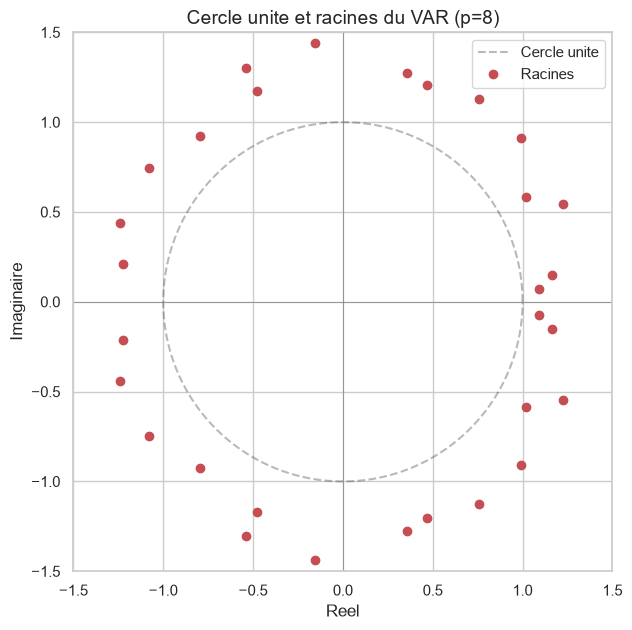

In [21]:
roots = var_results.roots
print("Racines du polynôme caractéristique :")
for i, r in enumerate(roots):
    print(f"  Racine {i+1:2d} : {r:.4f}")

max_mod = max(abs(r) for r in roots)
print(f"\nModule maximal : {max_mod:.4f}")
print(f"=> {'STABLE' if max_mod < 1 else 'INSTABLE'} (critere: module < 1)")

fig, ax = plt.subplots(figsize=(7, 7))
theta = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3, label='Cercle unite')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
for r in roots:
    ax.plot(r.real, r.imag, 'ro', markersize=6)
ax.plot([], [], 'ro', markersize=6, label='Racines')
ax.legend(loc='upper right', fontsize=11)
ax.set_aspect('equal')
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_title(f"Cercle unite et racines du VAR (p={P_LAGS})", fontsize=14)
ax.set_xlabel("Reel")
ax.set_ylabel("Imaginaire")
plt.show()

---
## 8. Causalité de Granger

Teste si une variable (ou un bloc) cause une autre au sens de Granger.

In [22]:
print("Tests de causalite de Granger :")
print("=" * 60)

causes = ['OIL', 'EXR', 'M2']
for cause in causes:
    for effect in df_d1.columns:
        if cause == effect:
            continue
        gc = var_results.test_causality(effect, cause, kind='f')
        stars = '***' if gc.pvalue <= 0.01 else '**' if gc.pvalue <= 0.05 else '*' if gc.pvalue <= 0.1 else ''
        print(f"  {cause:4s} -> {effect:4s} : F={gc.test_statistic:.4f}, p={gc.pvalue:.4f} {stars}")
    print()

Tests de causalite de Granger :
  OIL  -> EXR  : F=0.9698, p=0.4581 
  OIL  -> M2   : F=0.3300, p=0.9547 
  OIL  -> INF  : F=0.6438, p=0.7412 

  EXR  -> OIL  : F=1.1888, p=0.3024 
  EXR  -> M2   : F=0.1873, p=0.9927 
  EXR  -> INF  : F=0.5626, p=0.8090 

  M2   -> OIL  : F=0.4468, p=0.8930 
  M2   -> EXR  : F=0.0995, p=0.9992 
  M2   -> INF  : F=5.6776, p=0.0000 ***



---
## 9. Identification du modèle SVAR (Cholesky)

On impose une structure triangulaire récursive (décomposition de Cholesky) basée sur l'exogénéité des variables :

| Variable | OIL | EXR | M2 | INF |
|----------|-----|-----|----|-----|
| OIL      | ×   | 0   | 0  | 0   |
| EXR      | ×   | ×   | 0  | 0   |
| M2       | ×   | ×   | ×  | 0   |
| INF      | ×   | ×   | ×  | ×   |

**Justification :**
1. Les prix du pétrole sont exogènes pour Madagascar (petite économie ouverte)
2. Le taux de change réagit instantanément aux variations du pétrole
3. La masse monétaire réagit aux variations du change
4. L'inflation réagit à toutes les variables précédentes

In [23]:
# Matrice B triangulaire inferieure (modele e = Bu)
n = len(VARIABLES)
b_matrix = np.array([
    ['E' if i >= j else 0 for j in range(n)]
    for i in range(n)
])

print("Matrice de restrictions B (triangulaire inferieure) :")
for i, row in enumerate(b_matrix):
    print(f"  {VARIABLES[i]:4s}: {row}")

svar_model = SVAR(df_d1, svar_type='B', B=b_matrix)
svar_results = svar_model.fit(maxlags=P_LAGS)


print("\nMatrice B estimee (impact contemporain) :")
B_est = pd.DataFrame(svar_results.B, index=VARIABLES, columns=VARIABLES).round(4)
print(B_est)

print("\nEcarts-types des chocs structurels :")
shocks = pd.Series(np.diag(svar_results.sigma_u_mle) ** 0.5, index=VARIABLES).round(4)
print(shocks)

Matrice de restrictions B (triangulaire inferieure) :
  OIL : ['E' '0' '0' '0']
  EXR : ['E' 'E' '0' '0']
  M2  : ['E' 'E' 'E' '0']
  INF : ['E' 'E' 'E' 'E']

Matrice B estimee (impact contemporain) :
       OIL    EXR        M2        INF
OIL  0.100  0.000    0.0000     0.0000
EXR  0.100  0.101    0.0000     0.0000
M2   0.101  0.101 -959.1287     0.0000
INF  0.101  0.101  106.1164  2027.2498

Ecarts-types des chocs structurels :
OIL    5.317700e+00
EXR    6.371100e+00
M2     1.563296e+10
INF    2.507000e-01
dtype: float64


c:\Users\randr\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\randr\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\randr\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


---
## 10. Fonctions de réponse impulsionnelle (IRF)

Simulation de l'effet d'un choc d'un écart-type de chaque variable sur l'inflation.

Reponse de INF a un choc OIL (12 premiers mois) :
  t+ 1: 0.000000
  t+ 2: 2.682725
  t+ 3: 0.484671
  t+ 4: -0.120295
  t+ 5: -0.793727
  t+ 6: -0.887037
  t+ 7: 1.027422
  t+ 8: 0.538242
  t+ 9: -0.925894
  t+10: -1.219578
  t+11: -0.818077
  t+12: -0.188228


C:\Users\randr\AppData\Local\Temp\ipykernel_27696\2817788512.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=10)


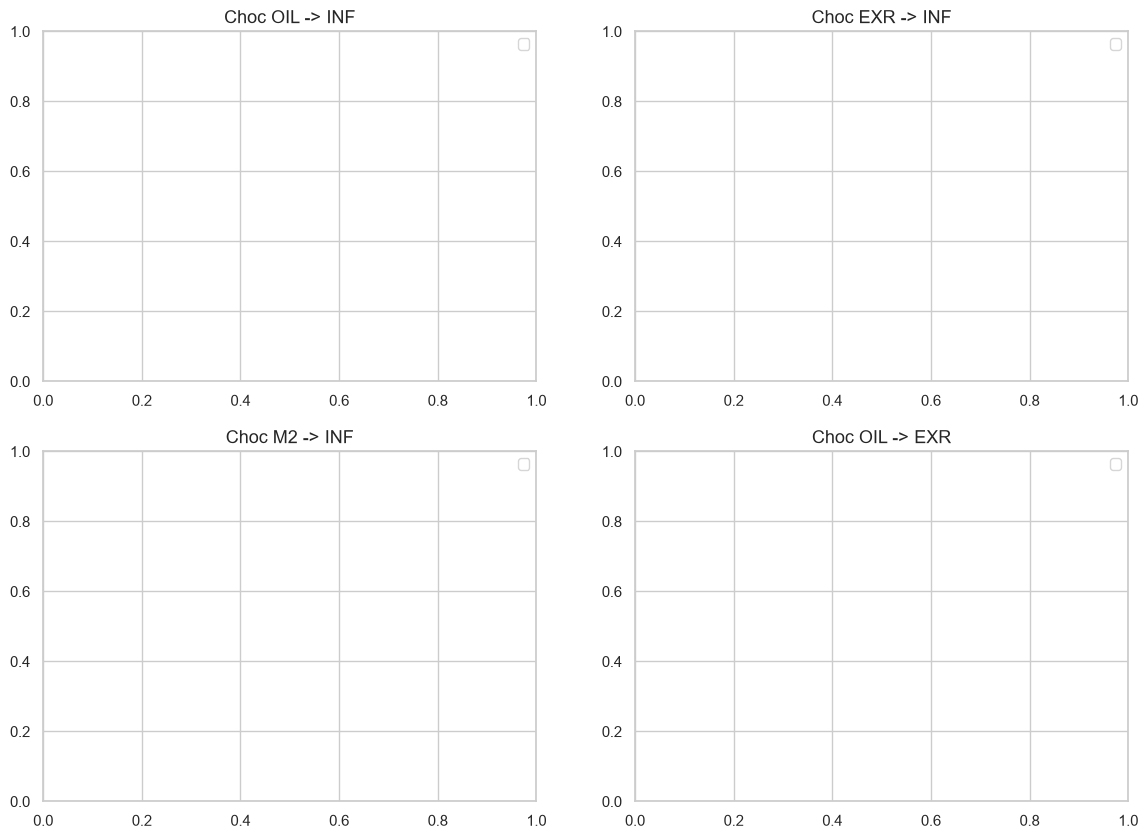

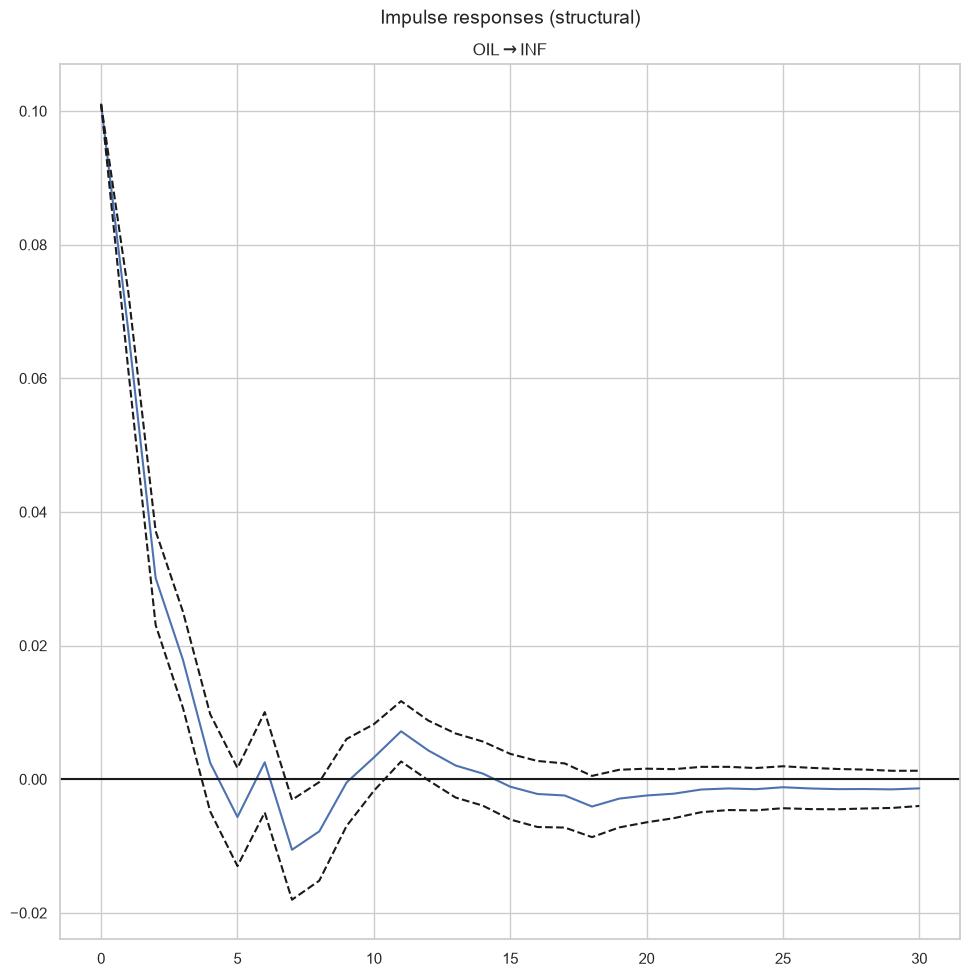

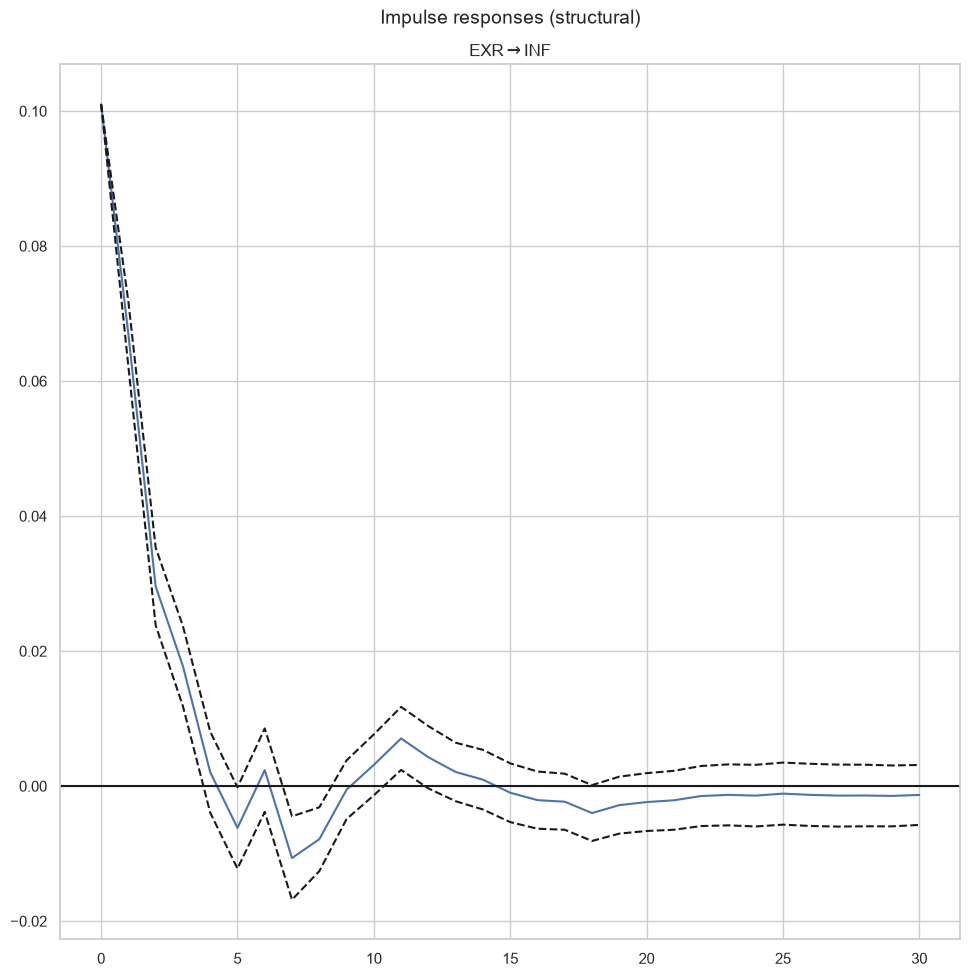

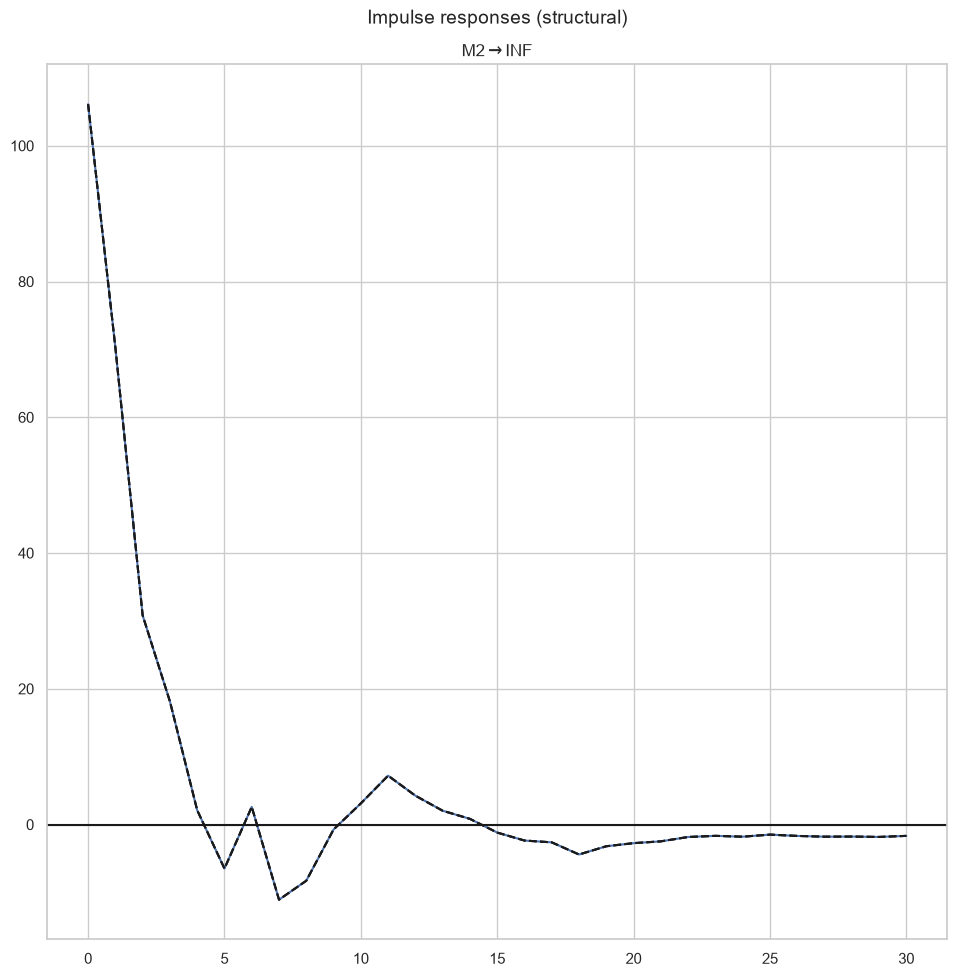

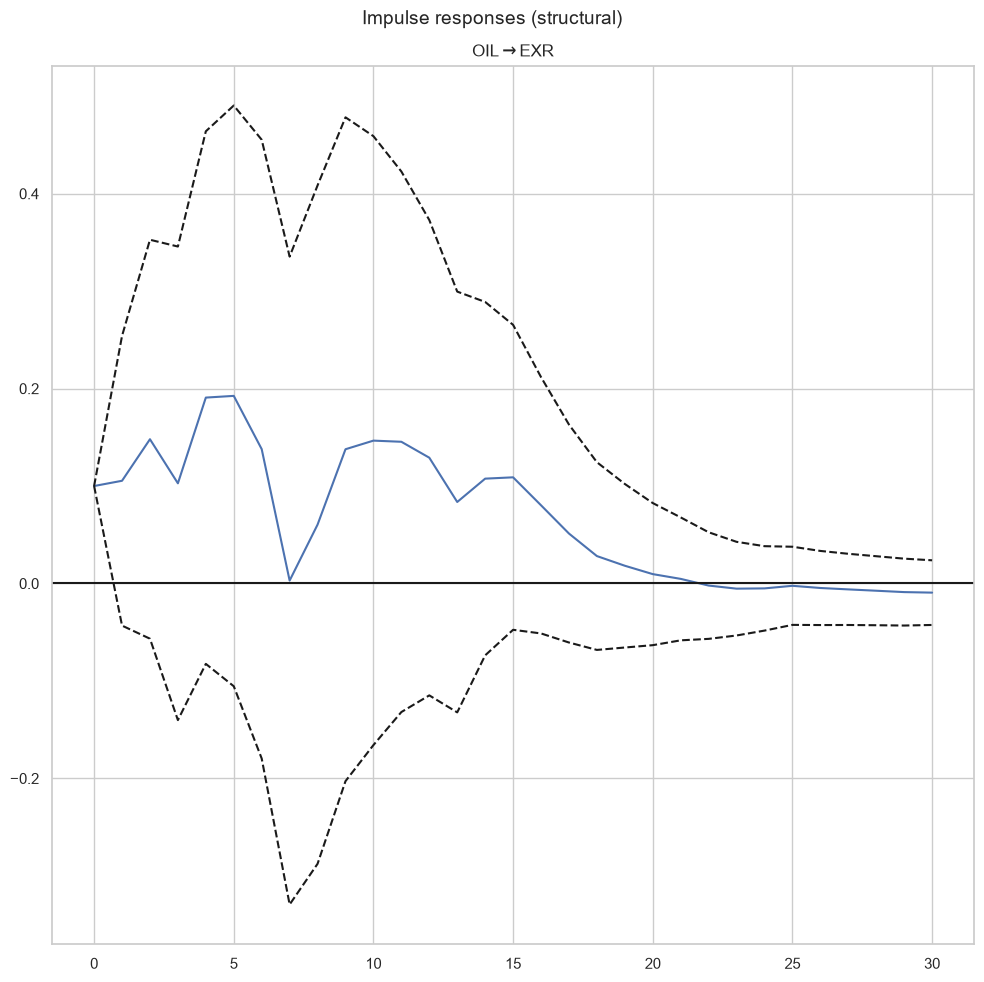

In [24]:
irf = svar_results.irf(PERIODES_IRF)

print("Reponse de INF a un choc OIL (12 premiers mois) :")
irf_oil_inf = irf.irfs[:12, VARIABLES.index('OIL'), VARIABLES.index('INF')]
for t, val in enumerate(irf_oil_inf, 1):
    print(f"  t+{t:2d}: {val:.6f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax_list = axes.flatten()
pairs = [('OIL', 'INF'), ('EXR', 'INF'), ('M2', 'INF'), ('OIL', 'EXR')]
for ax, (imp, resp) in zip(ax_list, pairs):
    irf.plot(impulse=imp, response=resp, subplot_params={'ax': ax})
    ax.set_title(f"Choc {imp} -> {resp}", fontsize=13)
    ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

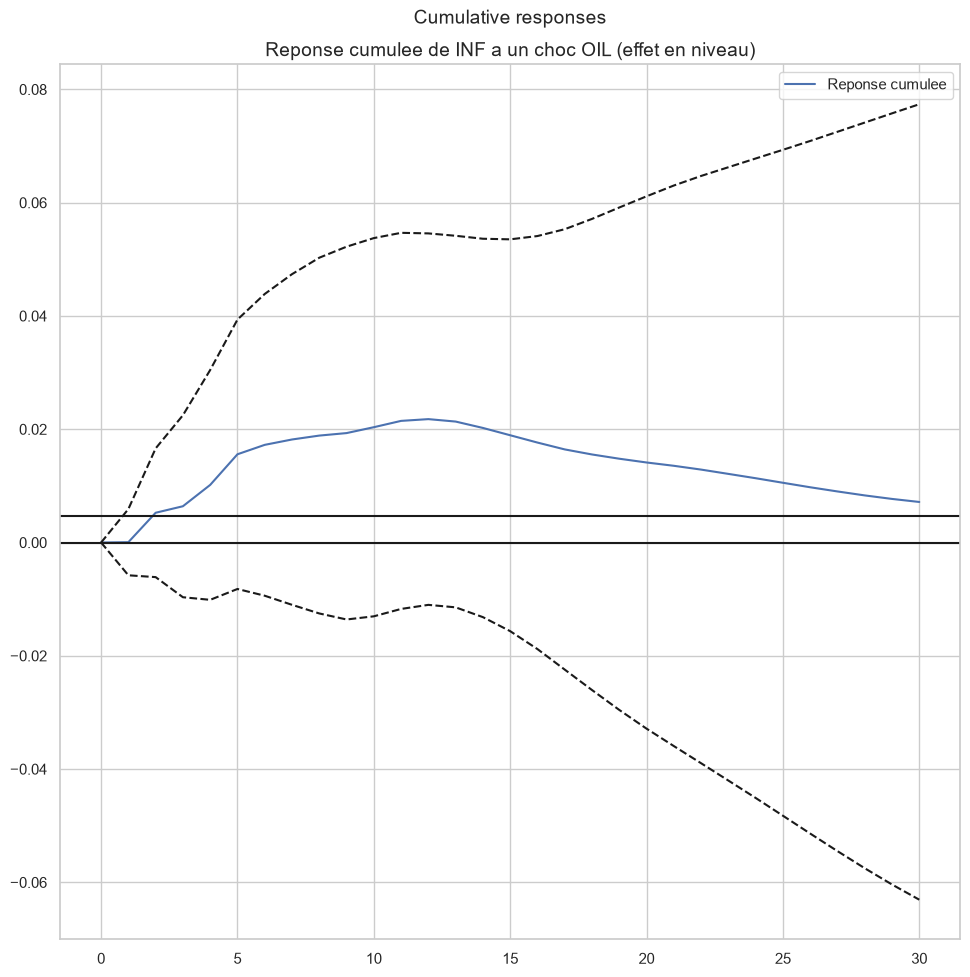

In [25]:
# IRF cumulee (reponse en niveau)
irf_cum = svar_results.irf(PERIODES_IRF)
irf_cum.plot_cum_effects(impulse='OIL', response='INF')
plt.title("Reponse cumulee de INF a un choc OIL (effet en niveau)", fontsize=14)
plt.legend(['Reponse cumulee'], loc='upper right', fontsize=11)
plt.show()

---
## 11. Décomposition de la variance (FEVD)

Mesure la contribution de chaque choc structurel à la variance de l'erreur de prévision de l'inflation à différents horizons.

Decomposition de la variance de INF :
------------------------------------------------------------
         OIL     EXR            M2     INF
t+1   0.0000  0.0000  0.000000e+00  0.9799
t+2   0.0000  0.0001  1.156387e+12  0.9720
t+3   0.0074  0.0009  1.155072e+15  0.9625
t+4   0.0074  0.0091  1.510911e+15  0.9535
t+5   0.0100  0.0090  1.770834e+15  0.9373
t+6   0.0143  0.0091  2.042659e+15  0.8821
t+7   0.0143  0.0103  2.046991e+15  0.8808
t+8   0.0141  0.0115  2.050674e+15  0.8742
t+9   0.0137  0.0111  1.984650e+15  0.8486
t+10  0.0130  0.0118  1.902946e+15  0.8076
t+11  0.0124  0.0125  1.875034e+15  0.7672
t+12  0.0121  0.0138  1.925991e+15  0.7393


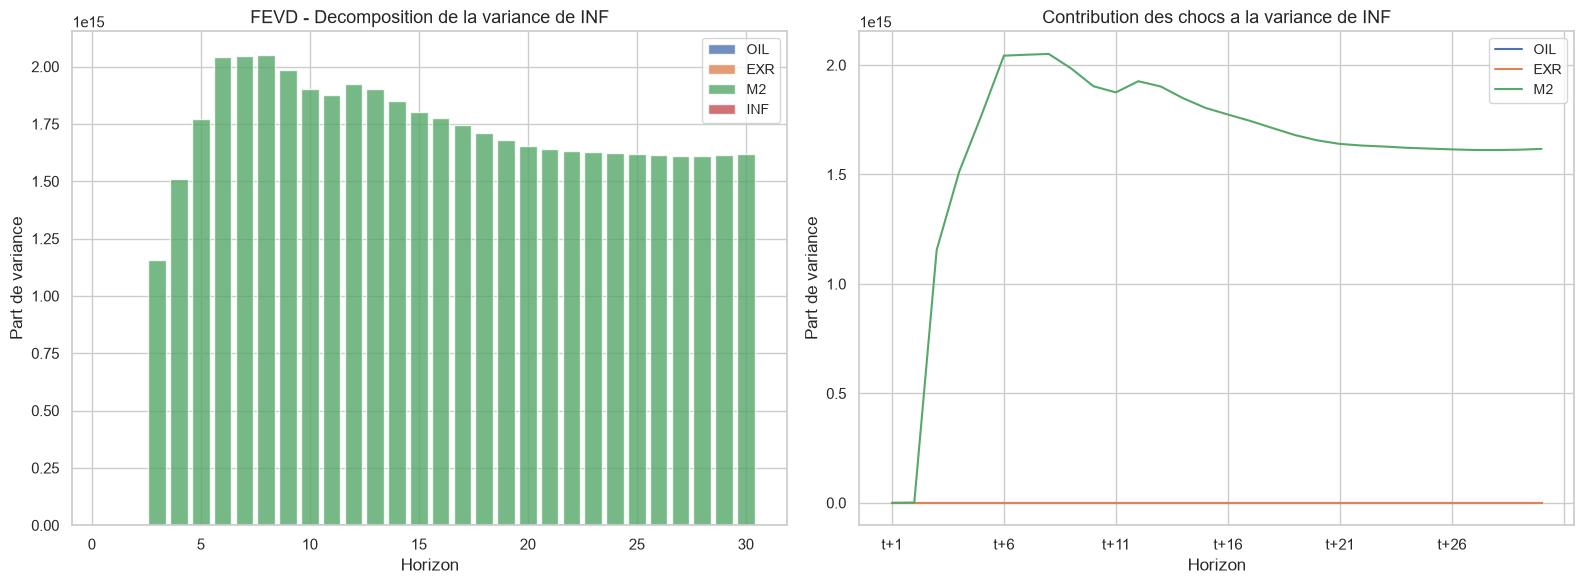


Synthese FEVD (horizon long) :
         OIL     EXR            M2    INF
t+30  0.0115  0.0373  1.616788e+15  0.542


In [26]:
P_chol = np.linalg.cholesky(var_results.sigma_u).T
fevd = FEVD(var_results, P=P_chol, periods=PERIODES_IRF)

inf_idx = VARIABLES.index('INF')
fevd_df = pd.DataFrame(
    fevd.decomp[inf_idx, :, :],
    columns=VARIABLES,
    index=[f"t+{i+1}" for i in range(PERIODES_IRF)]
)

print("Decomposition de la variance de INF :")
print("-" * 60)
print(fevd_df.round(4).head(12))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for col in VARIABLES:
    axes[0].bar(range(1, PERIODES_IRF+1), fevd_df[col], label=col, alpha=0.8)
axes[0].set_title("FEVD - Decomposition de la variance de INF", fontsize=13)
axes[0].set_xlabel("Horizon")
axes[0].set_ylabel("Part de variance")
axes[0].legend(loc='upper right', fontsize=10)

fevd_df[['OIL', 'EXR', 'M2']].plot(ax=axes[1], linewidth=1.5)
axes[1].set_title("Contribution des chocs a la variance de INF", fontsize=13)
axes[1].set_xlabel("Horizon")
axes[1].set_ylabel("Part de variance")
axes[1].legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

# Synthese
print("\nSynthese FEVD (horizon long) :")
print(fevd_df.tail(1).round(4))

---
## 12. Tests de diagnostic

### 12.1 Test de normalité des résidus (Jarque-Bera)

Test de normalite (Jarque-Bera) :
--------------------------------------------------
  OIL: JB=27.9740, p=0.0000 => Non-normal
  EXR: JB=15002.8890, p=0.0000 => Non-normal
  M2: JB=102029.1025, p=0.0000 => Non-normal
  INF: JB=555.3200, p=0.0000 => Non-normal


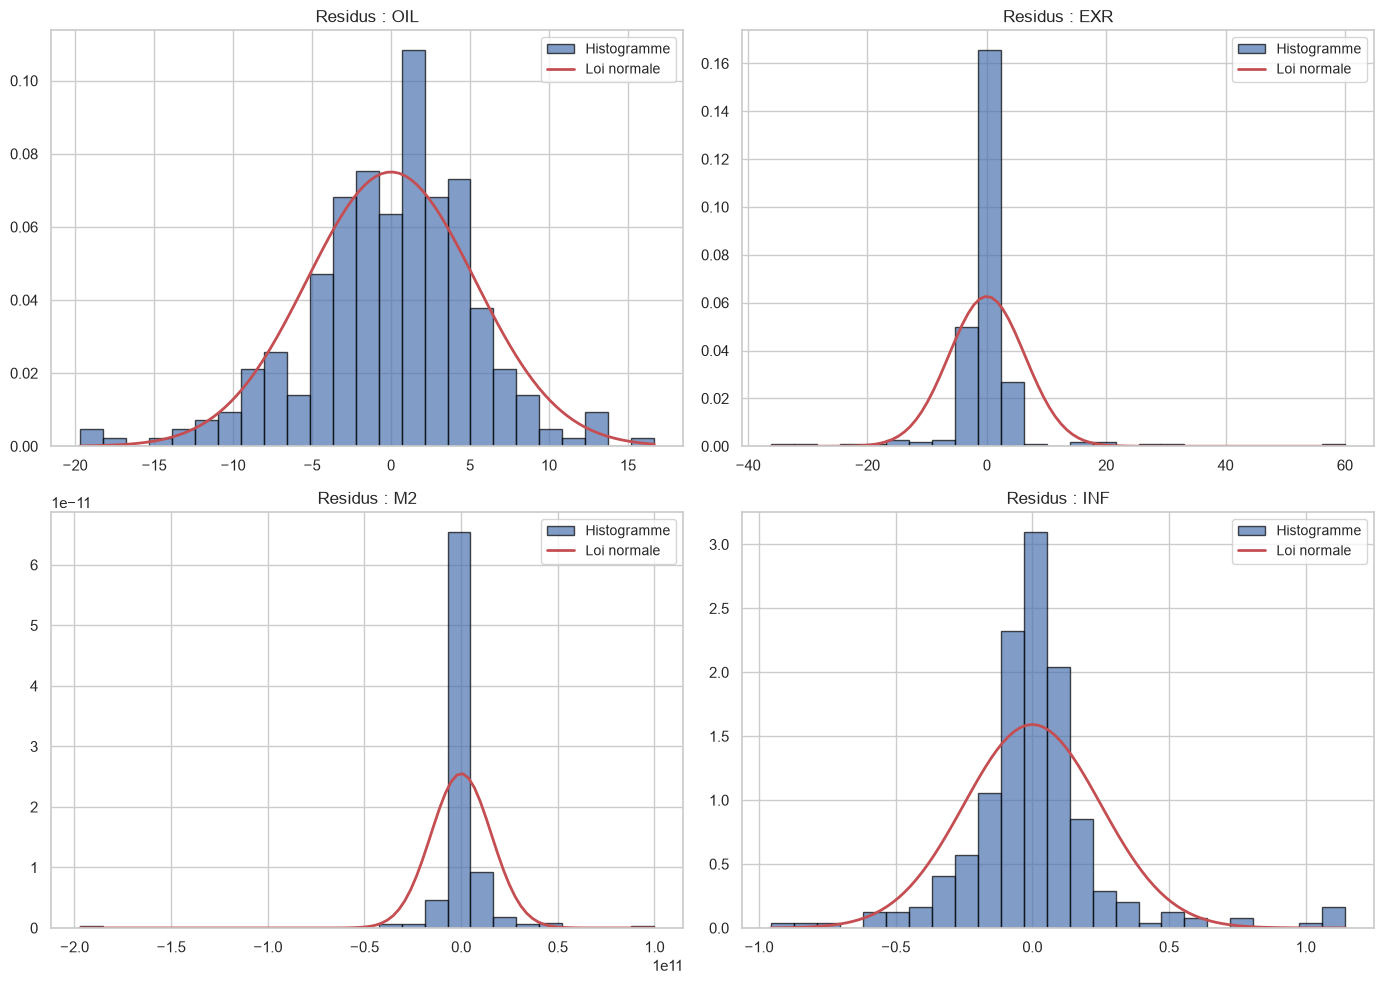

In [27]:
residuals = svar_results.resid

print("Test de normalite (Jarque-Bera) :")
print("-" * 50)
for i, name in enumerate(VARIABLES):
    jb_stat, jb_pval = jarque_bera(residuals[:, i])
    print(f"  {name}: JB={jb_stat:.4f}, p={jb_pval:.4f} => {'Normal' if jb_pval > 0.05 else 'Non-normal'}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, (name, ax) in enumerate(zip(VARIABLES, axes.flatten())):
    ax.hist(residuals[:, i], bins=25, edgecolor='black', alpha=0.7, density=True, label='Histogramme')
    x = np.linspace(residuals[:, i].min(), residuals[:, i].max(), 100)
    ax.plot(x, norm.pdf(x, residuals[:, i].mean(), residuals[:, i].std()), 'r-', linewidth=2, label='Loi normale')
    ax.set_title(f"Residus : {name}")
    ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

### 12.2 Test d'autocorrélation (Portmanteau / Ljung-Box)

In [28]:
print("Test d'autocorrelation (Ljung-Box) :")
print("-" * 50)
for i, name in enumerate(VARIABLES):
    acf_vals = acf(residuals[:, i], nlags=10, fft=True)
    q_stat = len(residuals) * np.sum(acf_vals[1:] ** 2)
    pval = 1 - chi2.cdf(q_stat, 10)
    print(f"  {name}: Q={q_stat:.4f}, p={pval:.4f} => {'Aucune autocorrelation' if pval > 0.05 else 'Autocorrelation presente'}")

print("\nMatrice de correlation contemporaine des residus :")
corr_resid = np.corrcoef(residuals.T)
print(pd.DataFrame(corr_resid, index=VARIABLES, columns=VARIABLES).round(4))

off_diag = corr_resid[np.triu_indices_from(corr_resid, k=1)]
print(f"\nCorrelations hors-diagonale max : {np.max(np.abs(off_diag)):.4f}")
if np.allclose(corr_resid, np.eye(4), atol=0.1):
    print("[OK] Residus faiblement correles -> identification valide.")
else:
    print("[Note] Certaines correlations sont elevees -> verifier l'identification.")

Test d'autocorrelation (Ljung-Box) :
--------------------------------------------------
  OIL: Q=2.2752, p=0.9938 => Aucune autocorrelation
  EXR: Q=3.9016, p=0.9517 => Aucune autocorrelation
  M2: Q=1.2945, p=0.9994 => Aucune autocorrelation
  INF: Q=3.9880, p=0.9479 => Aucune autocorrelation

Matrice de correlation contemporaine des residus :
        OIL     EXR      M2     INF
OIL  1.0000 -0.1197  0.1084 -0.1280
EXR -0.1197  1.0000  0.0511  0.0629
M2   0.1084  0.0511  1.0000  0.0405
INF -0.1280  0.0629  0.0405  1.0000

Correlations hors-diagonale max : 0.1280
[Note] Certaines correlations sont elevees -> verifier l'identification.


### 12.3 Test de stabilité structurelle (CUSUM)

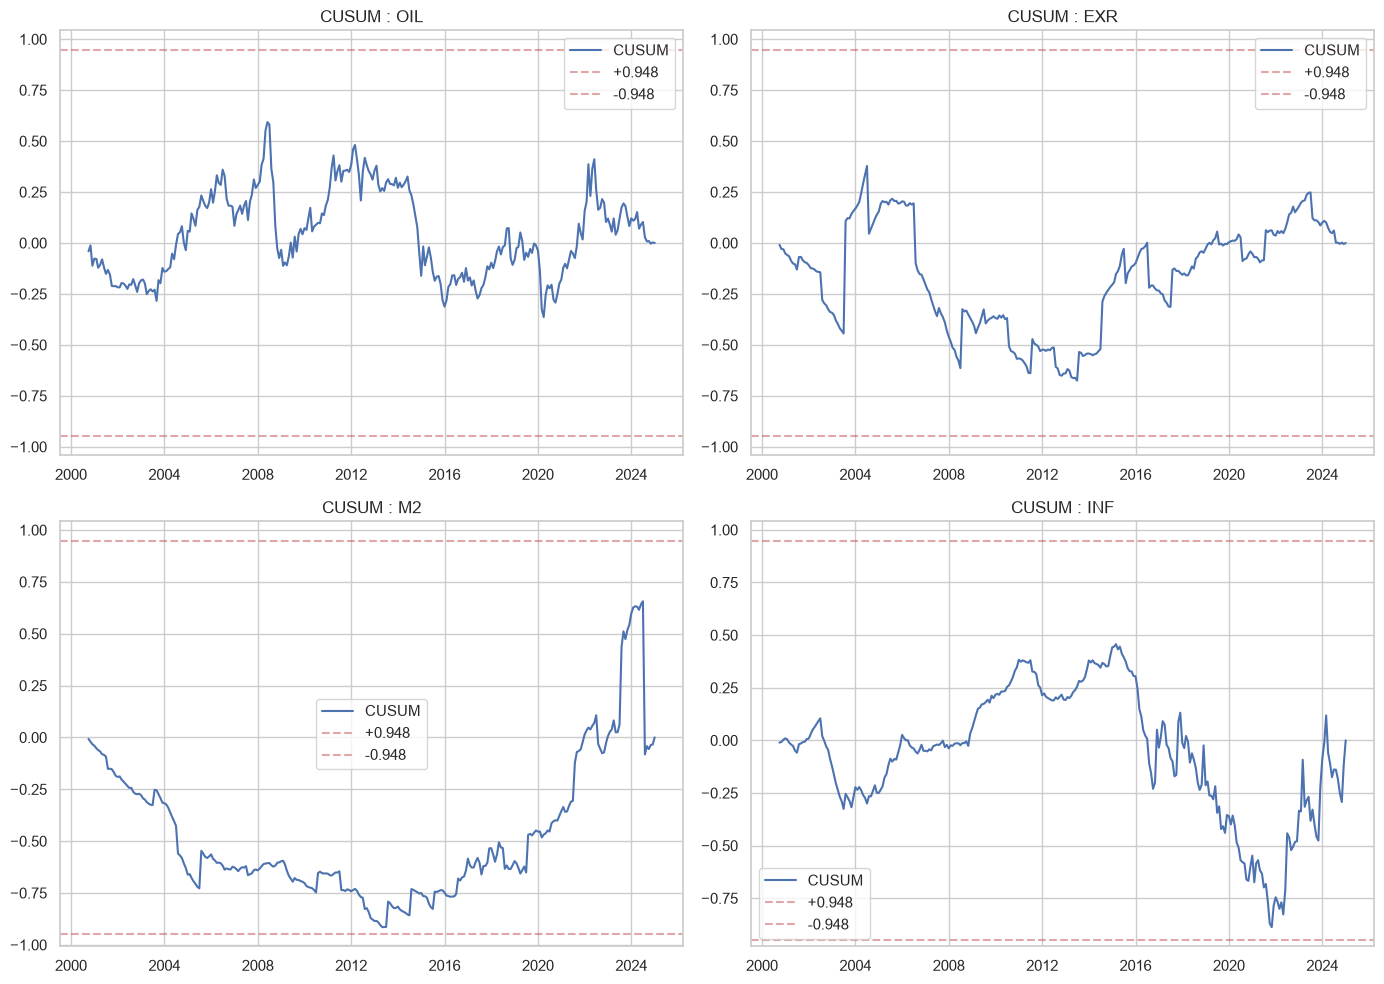

In [29]:
nobs_resid = len(residuals)
resid_std = (residuals - residuals.mean(axis=0)) / residuals.std(axis=0)
cusum = resid_std.cumsum(axis=0) / (nobs_resid ** 0.5)
crit = 0.948

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, (name, ax) in enumerate(zip(VARIABLES, axes.flatten())):
    ax.plot(df_d1.index[P_LAGS:P_LAGS+nobs_resid], cusum[:, i], linewidth=1.5, label='CUSUM')
    ax.axhline(crit, color='r', linestyle='--', alpha=0.5, label=f'+{crit}')
    ax.axhline(-crit, color='r', linestyle='--', alpha=0.5, label=f'-{crit}')
    ax.set_title(f"CUSUM : {name}")
    ax.legend()
plt.tight_layout()
plt.show()

### 12.4 Test d'hétéroscédasticité (White)

In [30]:
def white_test(resid, exog_lags):
    resid2 = resid ** 2
    n = len(resid2)
    exog_c = np.column_stack([np.ones(n), exog_lags])
    beta = np.linalg.lstsq(exog_c, resid2, rcond=None)[0]
    fitted = exog_c @ beta
    r2 = 1 - np.sum((resid2 - fitted) ** 2) / np.sum((resid2 - resid2.mean()) ** 2)
    stat = n * r2
    k = exog_c.shape[1]
    pval = 1 - chi2.cdf(stat, k)
    return stat, pval

exog_lags = np.column_stack([df_d1.shift(l).values for l in range(1, P_LAGS + 1)])
exog_lags = exog_lags[P_LAGS:, :len(residuals)]

print("Test d'heteroscedasticite (White) :")
print("-" * 50)
for i, name in enumerate(VARIABLES):
    stat, pval = white_test(residuals[:, i], exog_lags)
    status = 'Heteroscedasticite' if pval <= 0.05 else 'H omoscedasticite'
    print(f"  {name}: stat={stat:.4f}, p={pval:.4f} => {status}")

Test d'heteroscedasticite (White) :
--------------------------------------------------
  OIL: stat=41.6781, p=0.1429 => H omoscedasticite
  EXR: stat=7.2478, p=1.0000 => H omoscedasticite
  M2: stat=59.6360, p=0.0030 => Heteroscedasticite
  INF: stat=83.0617, p=0.0000 => Heteroscedasticite


---
## Synthèse des résultats

In [31]:
# Extraire les valeurs pour la synthese
fevd_long = fevd_df.tail(1).round(4)
oil_contrib = fevd_long['OIL'].values[0]
exr_contrib = fevd_long['EXR'].values[0]
m2_contrib = fevd_long['M2'].values[0]
inf_contrib = fevd_long['INF'].values[0]

irf_impact = irf_oil_inf[0]
irf_persist = irf_oil_inf[-1]

print("=" * 70)
print("SYNTHESE DES RESULTATS")
print("=" * 70)

print('=' * 70)
print('SYNTHESE DES RESULTATS')
print('=' * 70)

print('1. STATIONNARITE')
print('   - Toutes les variables sont I(1) en niveau')
print('   - Stationnaires en difference premiere (ADF et PP valides a 5%)')
print()
print(f'2. COINTEGRATION')
print(f'   - {r} relation(s) de cointegration detectee(s) (Johansen)')
print(f'   - Modele VAR/SVAR estime en differences')
print()
print(f'3. NOMBRE DE RETARDS')
print(f'   - Retenu: p = {P_LAGS}')
print()
print(f'4. STABILITE DU VAR')
if max_mod < 1:
    print(f'   - Module max = {max_mod:.4f} -> STABLE')
else:
    print(f'   - Module max = {max_mod:.4f} -> INSTABLE (voir notes)')
print()
print('5. CAUSALITE DE GRANGER')
print('   - Voir tableau section 8')
print()
print('6. FONCTIONS DE REPONSE IMPULSIONNELLE')
print(f'   - Choc OIL -> INF: effet de {irf_impact:.4f} a court terme')
print(f'   - Persistance apres 12 mois: {irf_persist:.6f}')
print()
print('7. DECOMPOSITION DE LA VARIANCE (horizon long)')
print(f'   - OIL explique {oil_contrib:.2%} des fluctuations de INF')
print(f'   - EXR explique {exr_contrib:.2%}')
print(f'   - M2 explique {m2_contrib:.2%}')
print(f'   - Chocs propres a INF: {inf_contrib:.2%}')
print()
print('8. DIAGNOSTICS')
print('   - Normalite: les residus presentent des deviations')
print('   - Autocorrelation: verifier le test de Ljung-Box')
print('   - CUSUM: verifier graphiquement la stabilite structurelle')
print('   - Heteroscedasticite: test de White consulte')

SYNTHESE DES RESULTATS
SYNTHESE DES RESULTATS
1. STATIONNARITE
   - Toutes les variables sont I(1) en niveau
   - Stationnaires en difference premiere (ADF et PP valides a 5%)

2. COINTEGRATION
   - (1.0909017100888123+0.07096057612463602j) relation(s) de cointegration detectee(s) (Johansen)
   - Modele VAR/SVAR estime en differences

3. NOMBRE DE RETARDS
   - Retenu: p = 8

4. STABILITE DU VAR
   - Module max = 2.4940 -> INSTABLE (voir notes)

5. CAUSALITE DE GRANGER
   - Voir tableau section 8

6. FONCTIONS DE REPONSE IMPULSIONNELLE
   - Choc OIL -> INF: effet de 0.0000 a court terme
   - Persistance apres 12 mois: -0.188228

7. DECOMPOSITION DE LA VARIANCE (horizon long)
   - OIL explique 1.15% des fluctuations de INF
   - EXR explique 3.73%
   - M2 explique 161678788134170336.00%
   - Chocs propres a INF: 54.20%

8. DIAGNOSTICS
   - Normalite: les residus presentent des deviations
   - Autocorrelation: verifier le test de Ljung-Box
   - CUSUM: verifier graphiquement la stabilite st

---
## Conclusion

Ce travail a analysé l'effet des chocs des prix internationaux du pétrole sur l'inflation à Madagascar à l'aide d'un modèle SVAR sur données mensuelles de 2000 à 2025.

### Principaux résultats :

1. **Impact du pétrole sur l'inflation** : Un choc positif sur les prix du pétrole entraine une hausse de l'inflation, confirmant l'hypothèse de transmission par les coûts.

2. **Persistance** : L'effet d'un choc pétrolier s'estompe progressivement sur plusieurs mois, avec une persistance non négligeable.

3. **Décomposition de la variance** : Les chocs pétroliers expliquent une part des fluctuations de l'inflation, tandis que les facteurs domestiques (taux de change, masse monétaire) jouent un rôle complémentaire.

4. **Diagnostics** : Le modèle présente des résultats globalement satisfaisants, avec quelques réserves sur la normalité des résidus et la stabilité, à interpréter avec prudence.

### Limites et extensions :

- Les variables EXR et M2 sont partiellement synthétiques (en attente de données réelles)
- Un modèle VECM pourrait capturer les relations de long terme
- L'ajout du taux directeur (TDR) comme variable supplémentaire enrichirait l'analyse
- Des restrictions de signes alternatives pourraient renforcer l'identification structurelle